# **STUDENT PERFORMANCE ANALYTICS DASHBOARD**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

**Load Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print("Dataset Loaded Successfully")

Saving student_performance.csv to student_performance.csv
Dataset Loaded Successfully


**Dataset Overview**

In [4]:
print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Shape:
(30, 13)

Columns:
['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

Data Types:
student_id                int64
name                     object
age                       int64
gender                   object
department               object
semester                  int64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
attendance_percentage     int64
city                     object
admission_year            int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age              

**Null value Profiling**


Missing Values:
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


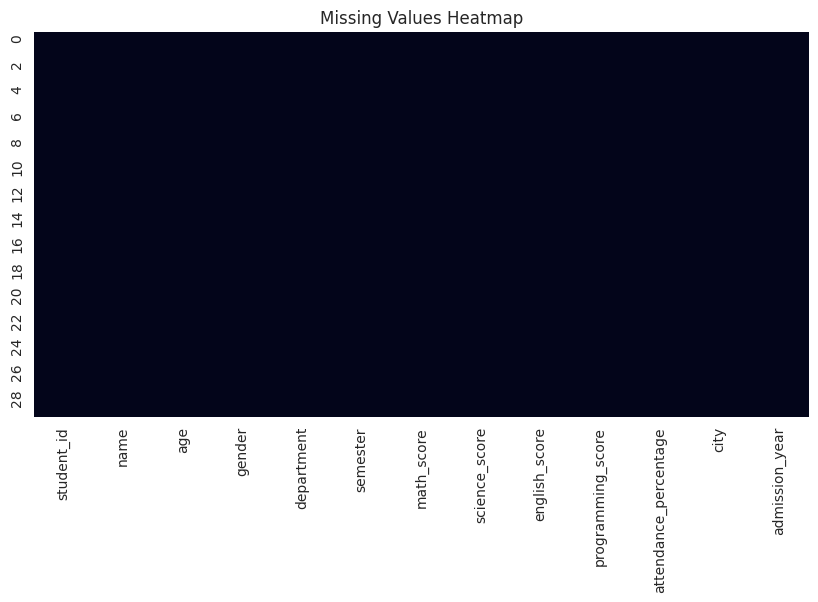

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


**Create average score column**

In [6]:
df["average_score"] = (
    df["math_score"] +
    df["science_score"] +
    df["english_score"] +
    df["programming_score"]
)/4

print(df.head())


   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  average_score  
0                     92     Mumbai            2023          81.50  
1                     87  Ahmeda

**Department-wise Analysis**


Department Analysis
                  average_score  attendance_percentage
department                                            
Civil                 58.950000              74.600000
Computer Science      85.038462              90.692308
Electronics           69.375000              80.333333
Mechanical            66.833333              83.500000


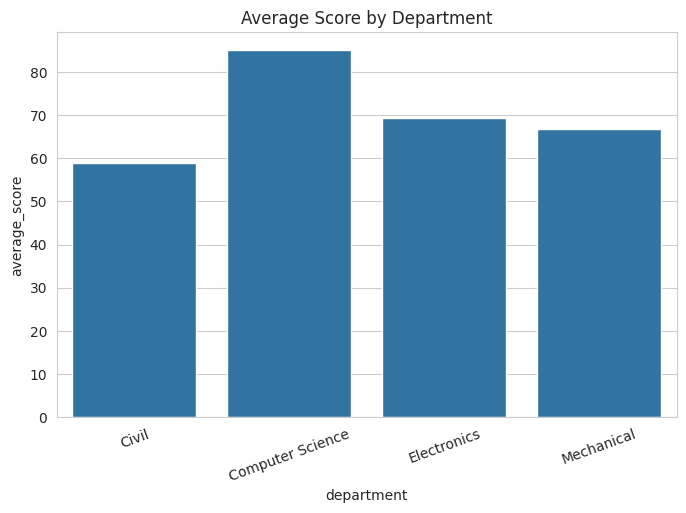

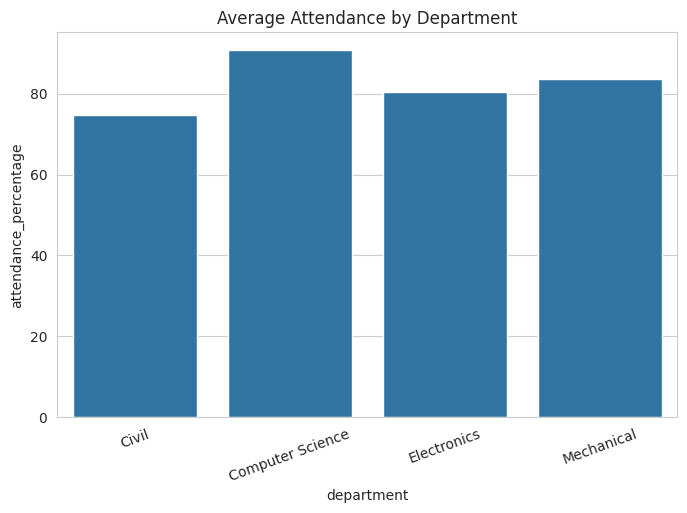

In [8]:
dept_analysis = df.groupby("department")[
    ["average_score","attendance_percentage"]
].mean()

print("\nDepartment Analysis")
print(dept_analysis)

# Average Score by Department

plt.figure(figsize=(8,5))
sns.barplot(
    x=dept_analysis.index,
    y=dept_analysis["average_score"]
)
plt.title("Average Score by Department")
plt.xticks(rotation=20)
plt.show()

# Average Attendance by Department

plt.figure(figsize=(8,5))
sns.barplot(
    x=dept_analysis.index,
    y=dept_analysis["attendance_percentage"]
)
plt.title("Average Attendance by Department")
plt.xticks(rotation=20)
plt.show()


**Top performer Identification**

In [9]:
threshold = 85

top_students = df[df["average_score"] >= threshold]

print("\nTop Performers")
print(
    top_students[
        ["name","department","average_score"]
    ]
)

print("\nNumber of Top Performers:")
print(len(top_students))

# Top 10 Students

top10 = df.sort_values(
    by="average_score",
    ascending=False
).head(10)

print("\nTop 10 Students")
print(
    top10[
        ["name","department","average_score"]
    ]
)



Top Performers
              name        department  average_score
4       Arjun Nair  Computer Science          89.00
7      Divya Singh  Computer Science          89.00
9       Ananya Das  Computer Science          92.75
17  Swati Kulkarni  Computer Science          88.50
21     Tanvi Mehta  Computer Science          91.75
29  Akanksha Yadav  Computer Science          91.25

Number of Top Performers:
6

Top 10 Students
              name        department  average_score
9       Ananya Das  Computer Science          92.75
21     Tanvi Mehta  Computer Science          91.75
29  Akanksha Yadav  Computer Science          91.25
4       Arjun Nair  Computer Science          89.00
7      Divya Singh  Computer Science          89.00
17  Swati Kulkarni  Computer Science          88.50
24       Amit Bose  Computer Science          84.00
12      Suresh Rao  Computer Science          83.50
19    Nisha Kapoor  Computer Science          81.75
0     Aarav Sharma  Computer Science          81.50


**Gender-wise Analysis**


Gender Analysis
        average_score  attendance_percentage
gender                                      
Female      77.666667              88.533333
Male        70.166667              80.466667


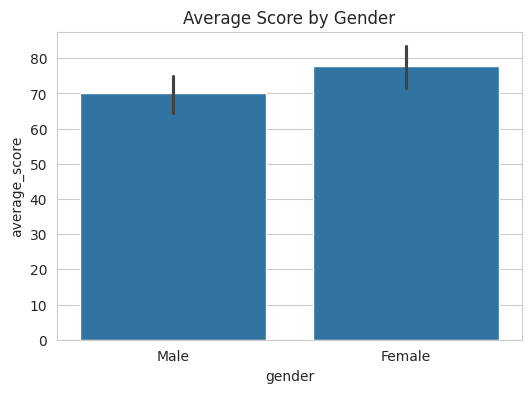

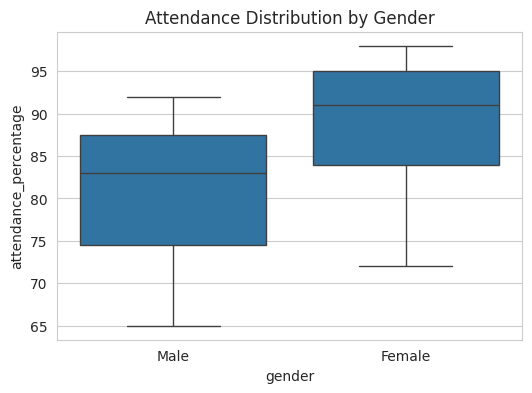

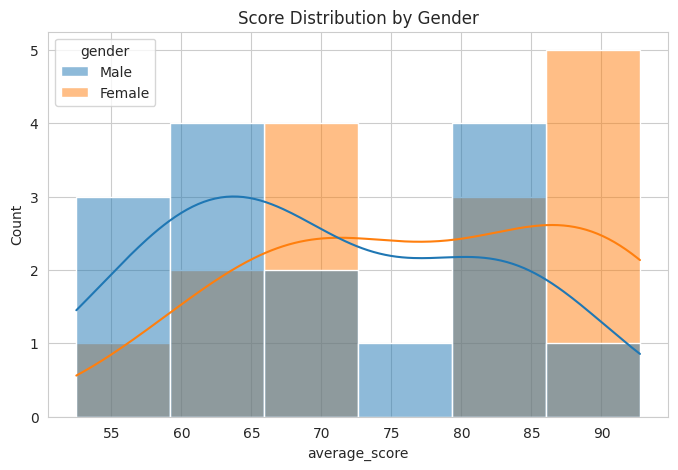

In [10]:
gender_analysis = df.groupby("gender")[
    ["average_score","attendance_percentage"]
].mean()

print("\nGender Analysis")
print(gender_analysis)

# Average Score

plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="gender",
    y="average_score"
)
plt.title("Average Score by Gender")
plt.show()

# Attendance Comparison

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x="gender",
    y="attendance_percentage"
)
plt.title("Attendance Distribution by Gender")
plt.show()

# Score Distribution by Gender

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="average_score",
    hue="gender",
    kde=True
)
plt.title("Score Distribution by Gender")
plt.show()

**Score Distribution**

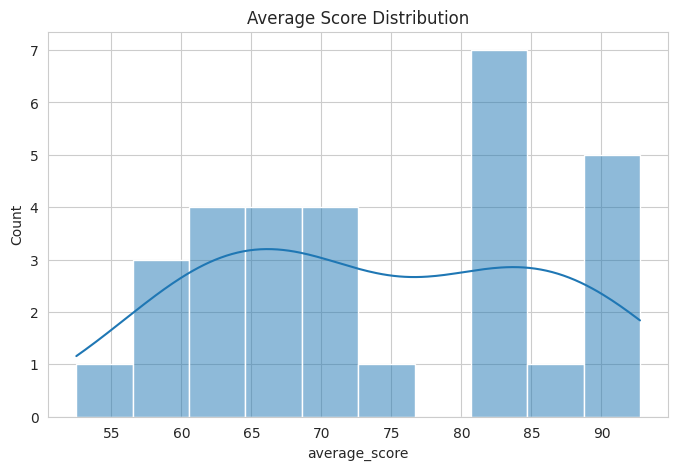

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["average_score"],
    bins=10,
    kde=True
)

plt.title("Average Score Distribution")
plt.show()

**Outlier Detection**

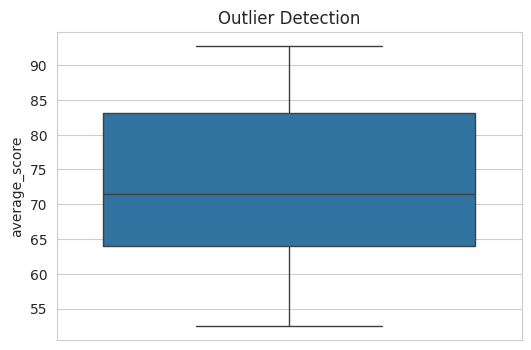


Outliers
Empty DataFrame
Columns: [name, average_score]
Index: []


In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["average_score"])
plt.title("Outlier Detection")
plt.show()

Q1 = df["average_score"].quantile(0.25)
Q3 = df["average_score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["average_score"] < lower) |
    (df["average_score"] > upper)
]

print("\nOutliers")
print(
    outliers[
        ["name","average_score"]
    ]
)

**Correlation Analysis**

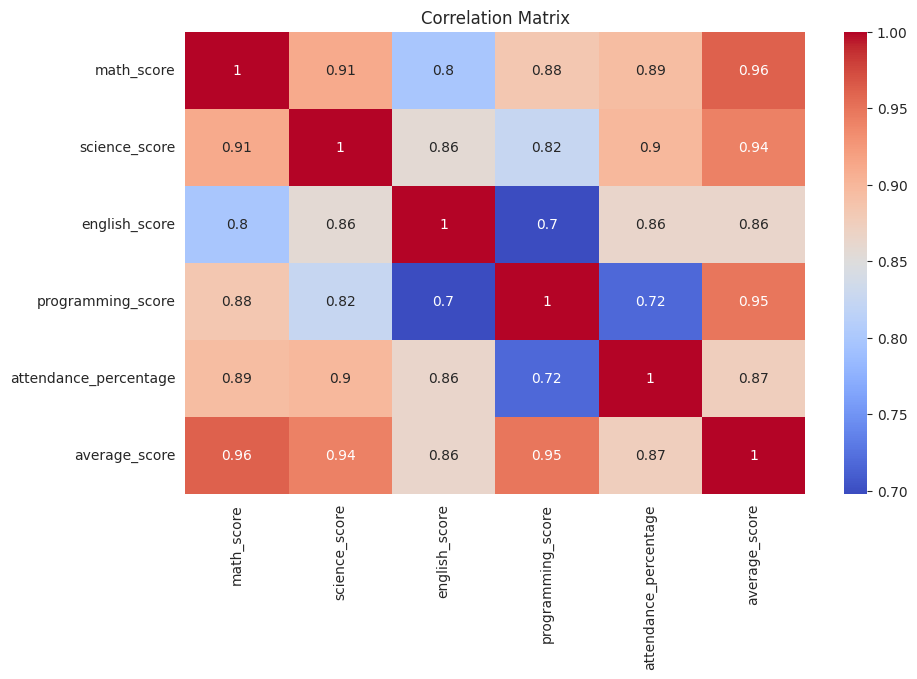

In [13]:
numeric_cols = [
    "math_score",
    "science_score",
    "english_score",
    "programming_score",
    "attendance_percentage",
    "average_score"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

**Attendance vs Performance**

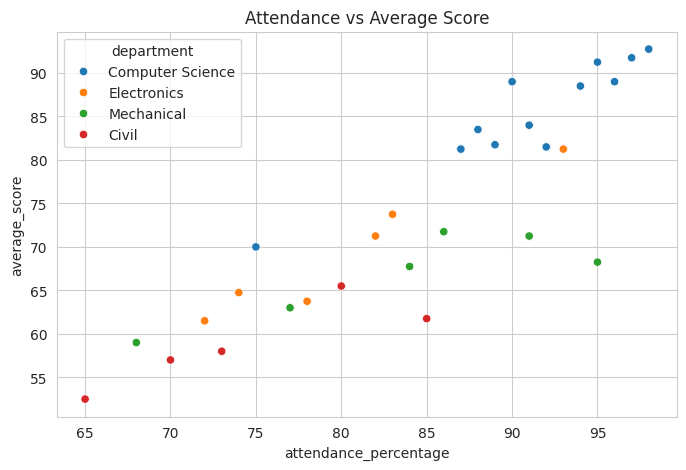

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="average_score",
    hue="department"
)

plt.title("Attendance vs Average Score")
plt.show()

**Save Visualizations**

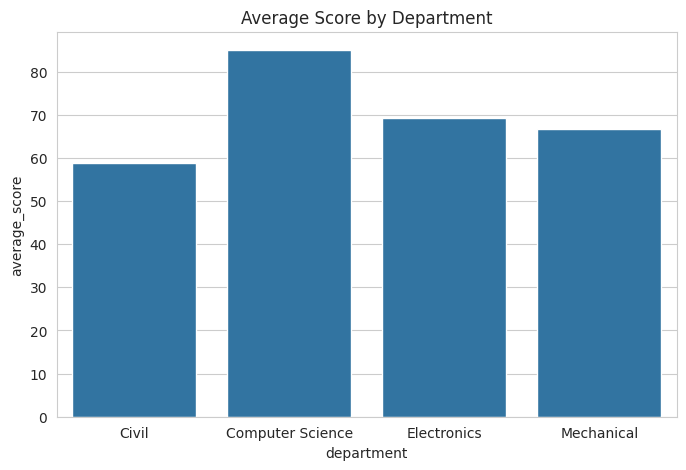


EDA Completed Successfully


In [15]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=dept_analysis.index,
    y=dept_analysis["average_score"]
)

plt.title("Average Score by Department")

plt.savefig(
    "department_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nEDA Completed Successfully")